Численные методы решения алгебраических уравнений (2.5) 

упр 1 

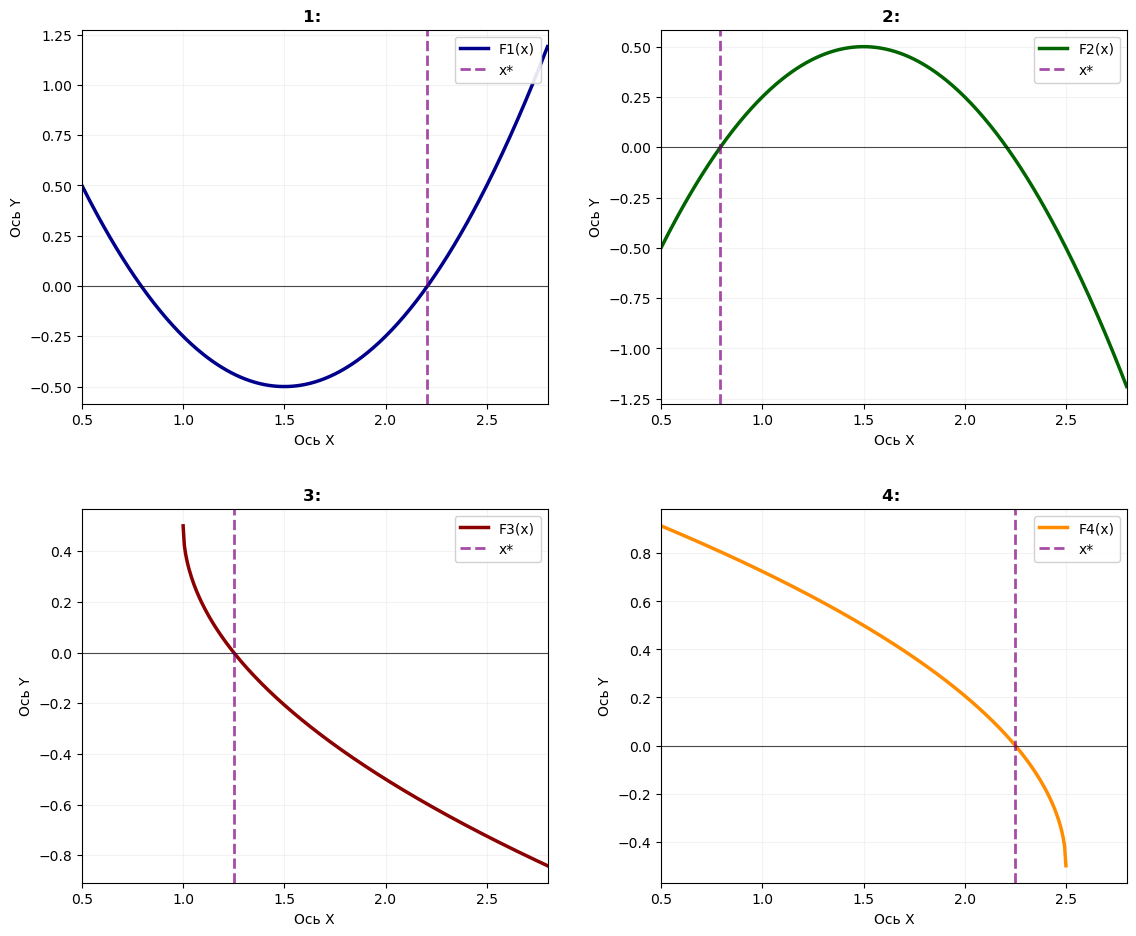

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def case1(x): return (x-1.5)**2 - 0.5
def case2(x): return -(x-1.5)**2 + 0.5
def case3(x): return -np.sqrt(x-1) + 0.5
def case4(x): return np.sqrt(2.5-x) - 0.5

functions = [case1, case2, case3, case4]

roots = [2.2071, 0.7929, 1.25, 2.25]
x_limits = [(0.5, 2.8), (0.5, 2.8), (1.0, 2.8), (0.5, 2.5)]
colors = ['darkblue', 'darkgreen', 'darkred', 'darkorange']

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

for i, ax in enumerate(axs.flat):
    x = np.linspace(x_limits[i][0], x_limits[i][1], 300)
    y = functions[i](x)
    
    ax.plot(x, y, color=colors[i], linewidth=2.5, label=f'F{i+1}(x)')
    ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.7)
    ax.axvline(x=roots[i], color='purple', linestyle='--', alpha=0.7, linewidth=2, label='x*')
    
    ax.set_title(f'{i+1}: ', fontweight='bold')
    ax.set_xlim(0.5, 2.8)
    ax.grid(True, alpha=0.15)
    ax.legend(loc='upper right', framealpha=0.9)
    ax.set_xlabel('Ось X')
    ax.set_ylabel('Ось Y')

plt.tight_layout(pad=3.0)
plt.show()

упр 2

In [7]:
import numpy as np
from tabulate import tabulate

def solve_equation():
    """Решение уравнения x³ + 3x² - 24x + 1 = 0"""
    
    def F(x): return x**3 + 3*x**2 - 24*x + 1
    def dF(x): return 3*x**2 + 6*x - 24
    def d2F(x): return 6*x + 6
    
    a, b, eps = 0, 1, 1e-6
    
    print("="*60)
    print("ЧИСЛЕННОЕ РЕШЕНИЕ НЕЛИНЕЙНОГО УРАВНЕНИЯ")
    print("="*60)
    
    # выбор стратегии
    if F(a) * d2F(a) > 0:
        fixed, moving, tangent = a, b, a
        side = "левом"
    else:
        fixed, moving, tangent = b, a, b
        side = "правом"
    
    print(f"Неподвижный конец: на {side} конце x = {fixed}")
    
    # итерационный процесс
    results = []
    x1, x2 = moving, tangent
    
    for n in range(1, 21):
        x1_new = (fixed * F(x1) - x1 * F(fixed)) / (F(x1) - F(fixed))
        x2_new = x2 - F(x2) / dF(x2)
        
        diff = abs(x1_new - x2_new)
        x_mid = (x1_new + x2_new) / 2
        
        results.append([n, f"{x1_new:.8f}", f"{x2_new:.8f}", 
                       f"{diff:.2e}", f"{F(x_mid):.2e}"])
        
        if diff < eps:
            print(tabulate(results, 
                          headers=["итер", "метод хорд", "метод касат", "|разн|", "F(x)"],
                          tablefmt="simple", numalign="right"))
            print(f"\nКОРЕНЬ: x = {x_mid:.10f}")
            print(f"Проверка: F(x) = {F(x_mid):.2e}")
            return x_mid
        
        x1, x2 = x1_new, x2_new
    
    return (x1 + x2) / 2

solve_equation()

ЧИСЛЕННОЕ РЕШЕНИЕ НЕЛИНЕЙНОГО УРАВНЕНИЯ
Неподвижный конец: на левом конце x = 0
  итер    метод хорд    метод касат    |разн|       F(x)
------  ------------  -------------  --------  ---------
     1          0.05      0.0416667   0.00833    -0.0936
     2     0.0419331      0.0418891  4.41e-05  -0.000523
     3     0.0418893      0.0418891  2.38e-07  -2.83e-06

КОРЕНЬ: x = 0.0418891852
Проверка: F(x) = -2.83e-06


0.04188918518497596